In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astroquery.jplhorizons import Horizons
from astropy.time import Time 

from orbit_correction import *

In [2]:
target_id = '799'           # Can be 'Neptune', 'Jupiter' 'Ceres', etc.
observer_id = '@tess'          # Can be any spacecraft, like 'JWST', 'Spitzer', etc.
flux_data_file = '/scratch11/ktp9/TESS_SolarSystem/Uranus/s44_cam1_ccd4/results_bps40_pps10/lc_Uranus_s44_cam1_ccd4.txt'

In [3]:
print("Parsing Light Curve")
times, raw_flux, start_date, end_date, step = get_lightcurve_info(flux_data_file)

print("Getting ephemeris")
delta = get_delta(target_id, start_date, end_date, step, location=observer_id)

print("Correcting Light curve")

corrected_lightcurve = correct_lightcurve(raw_flux, delta)


Parsing Light Curve
Getting ephemeris
Correcting Light curve


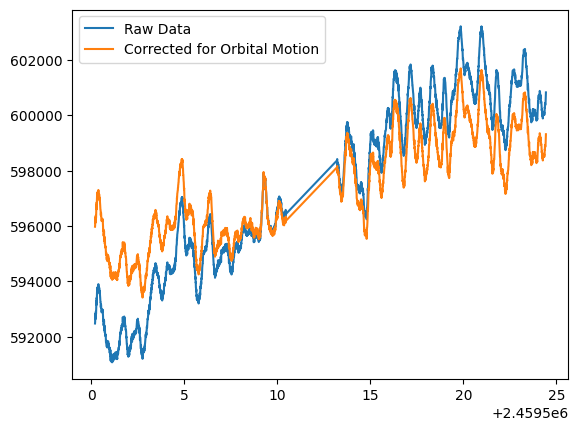

In [4]:
plt.plot(times, raw_flux, label="Raw Data")
plt.plot(times, corrected_lightcurve, label="Corrected for Orbital Motion")
plt.legend()
plt.show()